In [10]:
#a
import numpy as np
import pylab as plt

slice_point = []

def integrand(x):
    if x == 0:
        return 1.0
    else:
        return np.sin(x)**2/(x)**2
    
# recursive function
def step(x1,x2,f1,f2):
    global slice_points
    h = x2 - x1
    xm = (x1+x2)/2
    fm = integrand(xm)
    I1 = h/2 * (f1+f2)
    I2 = h/4 * (f1+2*fm+f2)
    error = abs(I2-I1)/3
    targeted_error = h * 1e-5

    if error <= targeted_error:
        slice_points.append(x1)
        slice_points.append(x2)
        return h/6 * (f1+4*fm+f2)
    else:
        return step(x1,xm,f1,fm) + step(xm,x2,fm,f2)   

# calculation   
a = 0
b = 10
f_a = integrand(0)
f_b = integrand(10)
result=step(0,10,f_a,f_b)
print(result)


1.51864575984341


In [ ]:
# =============================================================================
# PART b: Reason for Passing f(x1) and f(x2) as Arguments
# =============================================================================
# 1. The algorithm is recursive and continuously subdivides intervals. The 
#    boundaries of the new sub-slices are points whose function values 
#    were already computed in the parent step.
# 
# 2. If f(x1) and f(x2) were not passed as arguments, the program would 
#    re-evaluate the integrand f(x) at the same points repeatedly, leading 
#    to unnecessary computational overhead.
# 
# 3. Carrying these values along ensures each point is evaluated exactly 
#    once, resulting in an optimal and much faster execution.
# =============================================================================


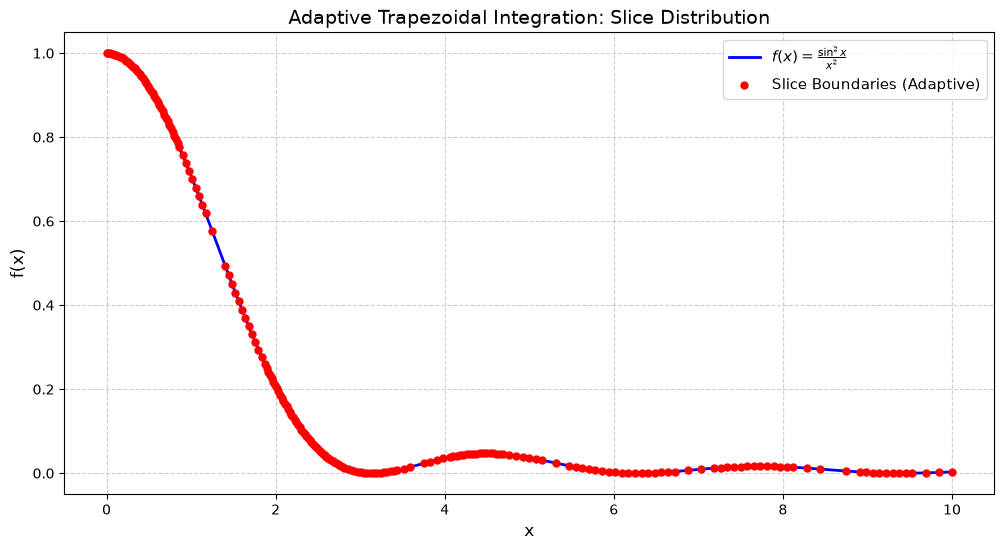

In [11]:
#c
slice_point.clear()

x_curve = np.linspace(0,10,100)
y_curve = [integrand(x) for x in x_curve]

unique_slices = sorted(list(set(slice_points)))
y_points = [integrand(x) for x in unique_slices]

plt.figure(figsize=(12,6))
plt.plot(x_curve,y_curve,'b-',label=r'$f(x) = \frac{\sin^2 x}{x^2}$',linewidth=2)
plt.scatter(unique_slices,y_points,color='red',s=25,zorder=3,label='Slice Boundaries (Adaptive)')
plt.title('Adaptive Trapezoidal Integration: Slice Distribution',fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()